In [ ]:
!pip install pandas matplotlib seaborn openpyxl

In [18]:
import pandas as pd
import os
import glob
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

root_path = Path(os.getcwd()).parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path / "src"))

from utils import TAG_INFO, THRESHOLDS

In [3]:
""" Import the complete dataset """

df = pd.read_excel('../data/raw/data_11-03_10-04.xlsx', sheet_name='Sheet1')

# Change the starting point of our data. Start where we data from all features
df["timestamp"]     = pd.to_datetime(df["timestamp"])
df                  = df.sort_values("timestamp").reset_index(drop=True)
first_complete_idx  = df.notna().all(axis=1).idxmax()
df_complete         = df.iloc[first_complete_idx:].reset_index(drop=True)

In [5]:
continuous_cols = ["PT-901", "PT-902", "PT-903",
                   "TT-901", "TT-902", "TT-903", "TT-904",
                   "FT-201", "FT-801", "FT-901",
                   "VSD-901_CORRENT", "VSD-901_POWER", "VSD-901_RPM", "VSD-901_SPEED"]

summary = df_complete[continuous_cols].describe().T
summary.columns = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
summary["unit"] = [TAG_INFO[col]["unit"] for col in summary.index]
summary["label"] = [TAG_INFO[col]["label"] for col in summary.index]
summary = summary[["label", "unit", "count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

summary

,label,unit,count,mean,std,min,25%,50%,75%,max
PT-901,Gas line inlet vacuum pressure,bar,39175.0,-0.681261,0.248792,-1.025101e+00,-0.833261,-0.721137,-0.551866,0.088325
PT-902,Gas line outlet vacuum pressure,bar,39175.0,0.014293,0.011896,-1.381654e-02,0.006221,0.011357,0.020399,0.050564
PT-903,Vacuum pressure in oil separator,bar,39175.0,0.066029,0.265176,-2.896296e+00,0.049769,0.081481,0.126389,0.259375
TT-901,Oil separator gas temperature,°C,39175.0,67.057679,5.048644,1.839193e+01,64.708115,67.485893,69.954422,77.083336
TT-902,Discharge 1 temperature,°C,39175.0,68.251732,4.955964,1.911893e+01,65.950523,68.630646,71.093750,78.114151
TT-903,Discharge 2 temperature,°C,39175.0,77.238675,5.234921,2.142470e+01,74.631073,77.696396,80.183918,88.395187
TT-904,Oil temperature,°C,39175.0,77.012884,5.493264,1.836480e+01,74.571396,77.468536,79.937065,87.917747
FT-201,Biogas inlet flow,Nm3/h,39175.0,621.789320,160.074010,-1.506076e+01,597.092041,652.126770,718.815094,826.258728
FT-801,Biomethane outlet flow,Nm3/h,39175.0,308.181333,87.328342,-8.000000e+02,303.588867,328.637695,352.563477,760.180603
FT-901,Exhaust gas flow,Nm3/h,39175.0,307.039863,235.333878,2.246094e+00,159.293617,266.699219,434.977219,929.003906


In [6]:
iqr_summary_rows = []

for col in continuous_cols:

    q1  = df_complete[col].quantile(0.25)
    q3  = df_complete[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask    = (df_complete[col] < lower_bound) | (df_complete[col] > upper_bound)
    n_outliers      = outlier_mask.sum()
    pct_outliers    = (n_outliers / len(df_complete)) * 100

    iqr_summary_rows.append({
        "tag":           col,
        "label":         TAG_INFO[col]["label"],
        "unit":          TAG_INFO[col]["unit"],
        "q1":            round(q1, 4),
        "q3":            round(q3, 4),
        "iqr":           round(iqr, 4),
        "lower_bound":   round(lower_bound, 4),
        "upper_bound":   round(upper_bound, 4),
        "n_outliers":    n_outliers,
        "pct_outliers":  round(pct_outliers, 2),
    })

iqr_summary = pd.DataFrame(iqr_summary_rows).set_index("tag")

iqr_summary

,label,unit,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
tag,,,,,,,,,
PT-901,Gas line inlet vacuum pressure,bar,-0.8333,-0.5519,0.2814,-1.2554,-0.1298,1445,3.69
PT-902,Gas line outlet vacuum pressure,bar,0.0062,0.0204,0.0142,-0.0150,0.0417,1324,3.38
PT-903,Vacuum pressure in oil separator,bar,0.0498,0.1264,0.0766,-0.0652,0.2413,525,1.34
TT-901,Oil separator gas temperature,°C,64.7081,69.9544,5.2463,56.8387,77.8239,579,1.48
TT-902,Discharge 1 temperature,°C,65.9505,71.0938,5.1432,58.2357,78.8086,556,1.42
TT-903,Discharge 2 temperature,°C,74.6311,80.1839,5.5528,66.3018,88.5132,549,1.40
TT-904,Oil temperature,°C,74.5714,79.9371,5.3657,66.5229,87.9856,621,1.59
FT-201,Biogas inlet flow,Nm3/h,597.0920,718.8151,121.7231,414.5075,901.3997,3900,9.96
FT-801,Biomethane outlet flow,Nm3/h,303.5889,352.5635,48.9746,230.1270,426.0254,3089,7.89


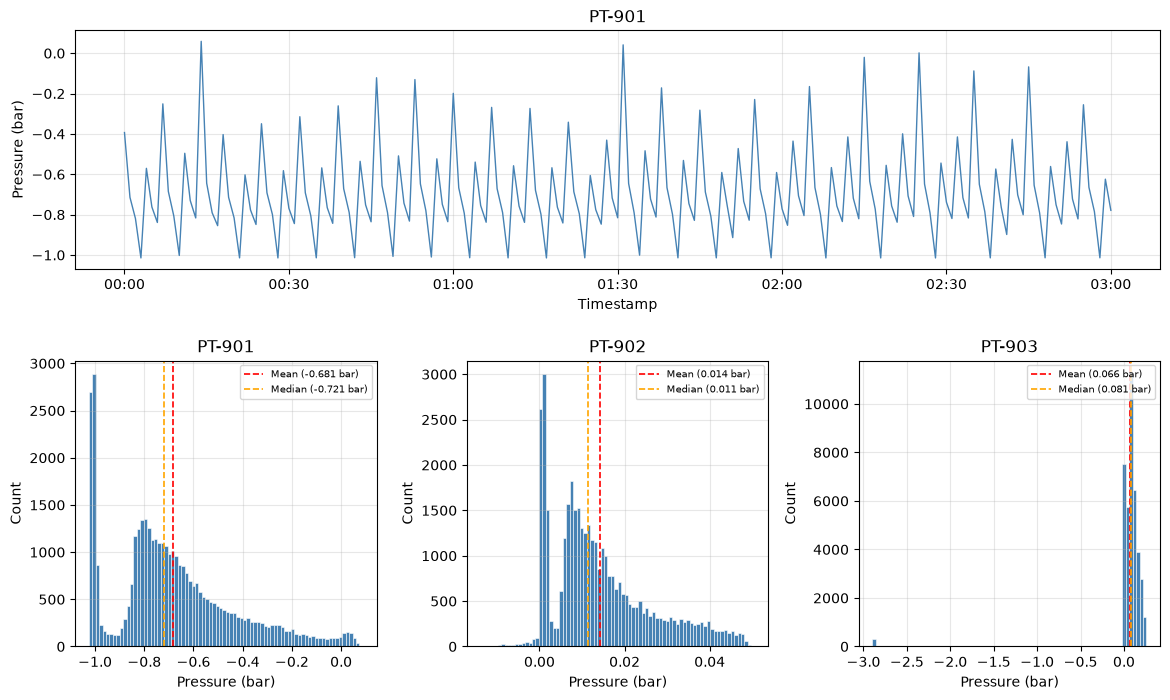

In [16]:
""" Combined figure: PT-901 cyclic behaviour + pressure distributions """

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.2], hspace=0.35, wspace=0.3)

# Top row: PT-901 zoomed time series (spans all 3 columns)
ax_top = fig.add_subplot(gs[0, :])

zoom_start = pd.Timestamp("2026-03-28 00:00:00")  # ajusta conforme necessário
zoom_end   = zoom_start + pd.Timedelta(hours=3)
mask = (df_complete["timestamp"] >= zoom_start) & (df_complete["timestamp"] <= zoom_end)
zoom_data = df_complete.loc[mask]

ax_top.plot(zoom_data["timestamp"], zoom_data["PT-901"], linewidth=1.0, color="steelblue")
ax_top.set_title("PT-901")
ax_top.set_xlabel("Timestamp")
ax_top.set_ylabel("Pressure (bar)")
ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_top.grid(True, alpha=0.3)

# Bottom row: three histograms
pressure_cols = ["PT-901", "PT-902", "PT-903"]
for i, col in enumerate(pressure_cols):
    ax = fig.add_subplot(gs[1, i])
    ax.hist(df_complete[col].dropna(), bins=80, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.axvline(df_complete[col].mean(), color="red", linewidth=1.2, linestyle="--",
               label=f"Mean ({df_complete[col].mean():.3f} bar)")
    ax.axvline(df_complete[col].median(), color="orange", linewidth=1.2, linestyle="--",
               label=f"Median ({df_complete[col].median():.3f} bar)")
    ax.set_title(col)
    ax.set_xlabel("Pressure (bar)")
    ax.set_ylabel("Count")
    ax.legend(loc="upper right", fontsize=7)
    ax.grid(True, alpha=0.3)

plt.savefig("eda_pt901_cycle_and_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

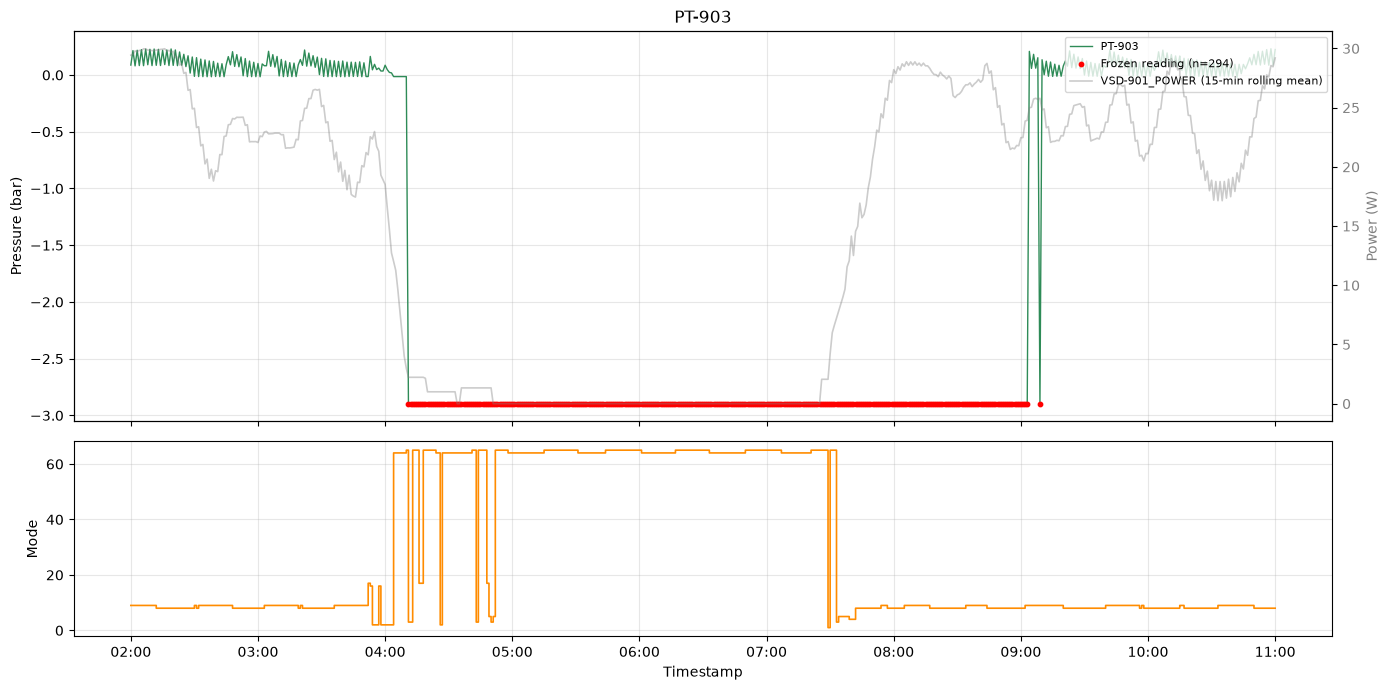

In [21]:
""" Zoomed view of the frozen PT-903 episode, with pump power (rolling mean) and Mode overlay """

zoom_start = pd.Timestamp("2026-04-07 02:00:00")
zoom_end   = pd.Timestamp("2026-04-07 11:00:00")

mask = (df_complete["timestamp"] >= zoom_start) & (df_complete["timestamp"] <= zoom_end)
zoom_data = df_complete.loc[mask].copy()

frozen_mask = np.isclose(zoom_data["PT-903"], -2.896296, atol=1e-4)

# Rolling mean of pump power (window in minutes, since data is 1-min sampled)
zoom_data["power_rolling"] = zoom_data["VSD-901_POWER"].rolling(window=15, center=True, min_periods=1).mean()

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 7), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# --- Top panel: PT-903 + pump power (rolling mean) on twin axis ---
ax1.plot(zoom_data["timestamp"], zoom_data["PT-903"], linewidth=1.0, color="seagreen", label="PT-903", zorder=3)
ax1.scatter(
    zoom_data.loc[frozen_mask, "timestamp"],
    zoom_data.loc[frozen_mask, "PT-903"],
    color="red", s=10, zorder=5,
    label=f"Frozen reading (n={frozen_mask.sum()})"
)
ax1.set_ylabel("Pressure (bar)")
ax1.set_title("PT-903")
ax1.grid(True, alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(
    zoom_data["timestamp"], zoom_data["power_rolling"],
    linewidth=1.2, color="gray", alpha=0.4, label="VSD-901_POWER (15-min rolling mean)", zorder=1
)
ax1_twin.set_ylabel("Power (W)", color="gray")
ax1_twin.tick_params(axis="y", labelcolor="gray")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)

# --- Bottom panel: Mode as a step plot ---
ax2.step(zoom_data["timestamp"], zoom_data["Mode"], where="post", color="darkorange", linewidth=1.2)
ax2.set_ylabel("Mode")
ax2.set_xlabel("Timestamp")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("eda_pt903_frozen_episode.png", dpi=200)
plt.show()

In [22]:
""" Investigate the exact -800 sentinel cluster in FT-801 """

sentinel_mask = df_complete["FT-801"] == -800.0
sentinel_subset = df_complete.loc[sentinel_mask, ["timestamp", "FT-801", "Mode"]]

print(f"Number of observations: {len(sentinel_subset)}")
print(f"Time range: {sentinel_subset['timestamp'].min()} to {sentinel_subset['timestamp'].max()}")
print(f"Mode distribution:\n{sentinel_subset['Mode'].value_counts()}")

sentinel_sorted = sentinel_subset.sort_values("timestamp")
time_diffs = sentinel_sorted["timestamp"].diff()
n_episodes = (time_diffs > pd.Timedelta(minutes=5)).sum() + 1
print(f"Estimated number of separate episodes (gap > 5 min): {n_episodes}")
print(sentinel_sorted)

Number of observations: 27
Time range: 2026-03-16 19:34:00 to 2026-04-08 21:57:00
Mode distribution:
Mode
8    16
9    11
Name: count, dtype: int64
Estimated number of separate episodes (gap > 5 min): 27
                timestamp  FT-801  Mode
5405  2026-03-16 19:34:00  -800.0     9
5703  2026-03-17 00:32:00  -800.0     8
8113  2026-03-18 16:40:00  -800.0     9
8655  2026-03-19 01:42:00  -800.0     9
9437  2026-03-19 14:51:00  -800.0     9
9637  2026-03-19 18:11:00  -800.0     8
11041 2026-03-20 17:35:00  -800.0     9
12135 2026-03-21 11:48:00  -800.0     8
12222 2026-03-21 13:15:00  -800.0     9
13308 2026-03-22 07:21:00  -800.0     8
14318 2026-03-23 19:18:00  -800.0     8
16022 2026-03-24 23:41:00  -800.0     8
16152 2026-03-25 01:51:00  -800.0     9
17026 2026-03-25 16:31:00  -800.0     8
19247 2026-03-27 05:32:00  -800.0     8
24210 2026-03-30 16:11:00  -800.0     8
26667 2026-04-01 09:09:00  -800.0     8
28658 2026-04-02 20:07:00  -800.0     8
29466 2026-04-03 09:35:00  -800.0   

Total time missing: 1 days 16:03:01.430000
Nr of jumps found: 77
time_diff
<=1 min      0
1-5min      33
5-30 min    37
30m-2h       3
2h-12h       4
>12h         0
Name: count, dtype: int64


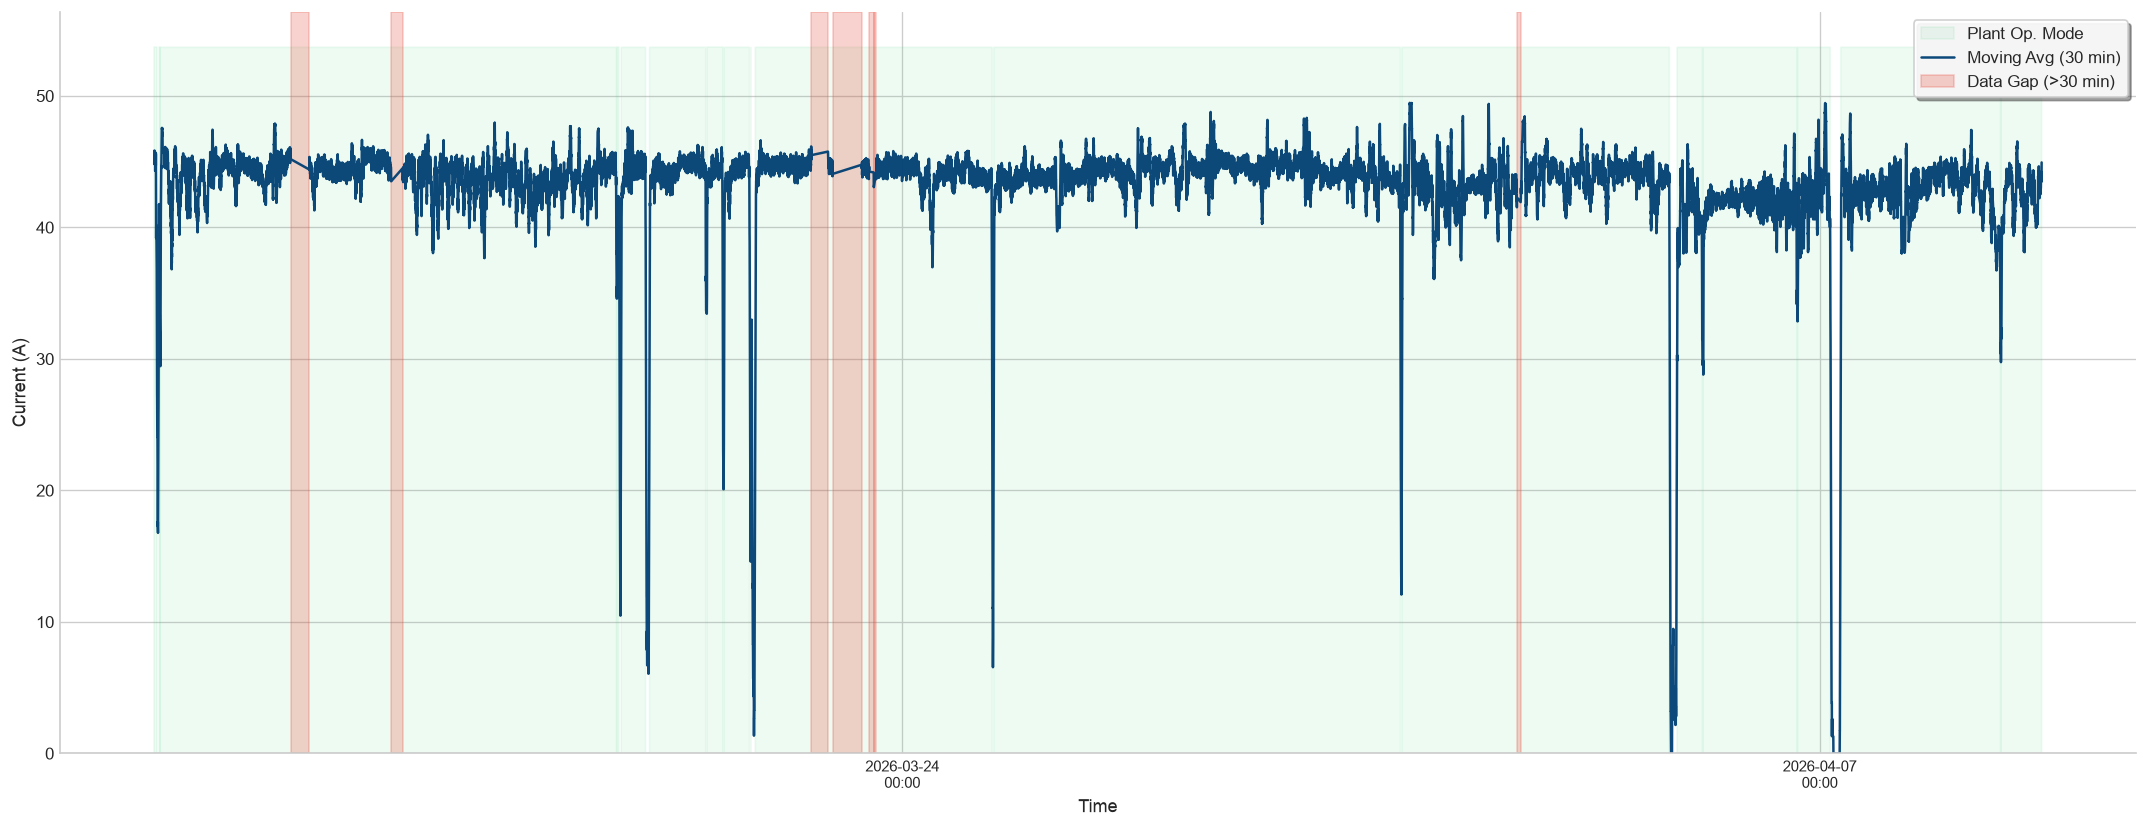

In [29]:
""" Detect timestamp gaps in the complete dataset """

df_complete["time_diff"] = df_complete["timestamp"].diff()
gaps = df_complete[df_complete["time_diff"] > pd.Timedelta(minutes=1)]

if not gaps.empty:
    total_time_lost = gaps["time_diff"].sum()
    print(f"Total time missing: {total_time_lost}")
    print(f"Nr of jumps found: {len(gaps)}")

""" Gap duration breakdown """

bins = [0, 1.01, 5, 30, 120, 720, float('inf')]
labels = ['<=1 min', '1-5min', '5-30 min', '30m-2h', '2h-12h', '>12h']

gap_category = pd.cut(gaps["time_diff"].dt.total_seconds() / 60, bins=bins, labels=labels)
print(gap_category.value_counts().sort_index())

""" Plot: pump current vs. large data gaps (>30 min), with moving average """

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(18, 7), dpi=120)

# Only the large gaps (>30 min), matching the session boundaries used in data cleaning
large_gaps = df_complete[df_complete["time_diff"] > pd.Timedelta(minutes=30)]

plant_on_mask = df_complete["Mode"].isin([8, 9])
current       = df_complete["VSD-901_CORRENT"]
timestamps    = df_complete["timestamp"]

# Mask out large gaps so the line breaks instead of connecting across them
current_masked = current.copy()
for idx, row in large_gaps.iterrows():
    end_gap   = row["timestamp"]
    start_gap = end_gap - row["time_diff"]
    gap_mask  = (timestamps >= start_gap) & (timestamps <= end_gap)
    current_masked[gap_mask] = float('nan')

# Moving average on masked signal
window_min = 30
ma = current_masked.rolling(window=window_min, center=True, min_periods=1).mean()

# Plant operating mode background
ax.fill_between(timestamps, 0, current.max(),
                where=plant_on_mask,
                color='#2ecc71', alpha=0.08, label='Plant Op. Mode')

# Moving average (prominent)
ax.plot(timestamps, ma,
        color='#003f73', linewidth=1.5, alpha=0.95,
        label=f'Moving Avg ({window_min} min)')

# Only the large gaps (>30 min)
for idx, row in large_gaps.iterrows():
    end_gap   = row["timestamp"]
    start_gap = end_gap - row["time_diff"]
    ax.axvspan(start_gap, end_gap,
               color='#e74c3c', alpha=0.25,
               label='Data Gap (>30 min)' if idx == large_gaps.index[0] else "")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=0, fontsize=9)

ax.set_ylim(bottom=0)
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel("Current (A)", fontsize=11)

ax.legend(loc='upper right', frameon=True, facecolor='white',
          framealpha=0.9, shadow=True, fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("eda_gaps_overview.png", dpi=200, bbox_inches="tight")
plt.show()